<a href="https://colab.research.google.com/github/hugo1911/ProyectoICOP2/blob/master/ICOP2_Deteccion_de_planta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasifiacion y deteccion de plantas saludables**

---



Descarga del data set https://www.kaggle.com/datasets/rashikrahmanpritom/plant-disease-recognition-dataset

In [8]:
#Libreria para descargar el dataset usando API
!pip install kagglehub -q

In [9]:
import os

#token que te da kaggle para descargar el data set
os.environ["KAGGLE_API_TOKEN"] = "KGAT_f02f85a2b7d40ec71deaf7bf6c3258c3"


import kagglehub
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print(path)

Using Colab cache for faster access to the 'plant-disease-recognition-dataset' dataset.
/kaggle/input/plant-disease-recognition-dataset


In [10]:
# ya que el dataset tiene Rutas diferentes se busca la estructura real del dataset
base = os.path.join(path, '1')

TRAIN_DIR = os.path.join(base, 'Train', 'Train')
VAL_DIR   = os.path.join(base, 'Validation', 'Validation')
TEST_DIR  = os.path.join(base, 'Test', 'Test')

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    status = 'Existe' if os.path.exists(d) else 'No existe'
    print(f"{status} {name}: {d}")

No existe Train: /kaggle/input/plant-disease-recognition-dataset/1/Train/Train
No existe Val: /kaggle/input/plant-disease-recognition-dataset/1/Validation/Validation
No existe Test: /kaggle/input/plant-disease-recognition-dataset/1/Test/Test


## 1. EDA

In [13]:
import torch
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

PyTorch version: 2.10.0+cu128
Dispositivo: cuda


In [14]:
import os


if os.path.exists('/kaggle/input'):
    # Entorno Kaggle
    base = '/kaggle/input/plant-disease-recognition-dataset'
else:
    # Entorno Colab
    base = os.path.join(path, '1')

# Buscar las carpetas Train/Validation/Test
def find_dir(base, names):
    for name in names:
        candidate = os.path.join(base, name, name)
        if os.path.exists(candidate):
            return candidate
        candidate = os.path.join(base, name)
        if os.path.exists(candidate):
            return candidate
    return None

TRAIN_DIR = find_dir(base, ['Train', 'train', 'training'])
VAL_DIR   = find_dir(base, ['Validation', 'validation', 'val'])
TEST_DIR  = find_dir(base, ['Test', 'test'])

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    status = 'Existe' if d and os.path.exists(d) else 'No existe'
    print(f"{status} {name}: {d}")

Existe Train: /kaggle/input/plant-disease-recognition-dataset/Train/Train
Existe Val: /kaggle/input/plant-disease-recognition-dataset/Validation/Validation
Existe Test: /kaggle/input/plant-disease-recognition-dataset/Test/Test


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import seaborn as sns

In [17]:
# Clases disponibles
classes = sorted(os.listdir(TRAIN_DIR))
num_classes = len(classes)
print(f"Total de clases: {num_classes}")
for c in classes:
    print(c)

Total de clases: 3
Healthy
Powdery
Rust


         Train  Validacion  Test
Healthy    458          20    50
Powdery    430          20    50
Rust       434          20    50

Total — Train: 1322 | Val: 60 | Test: 150


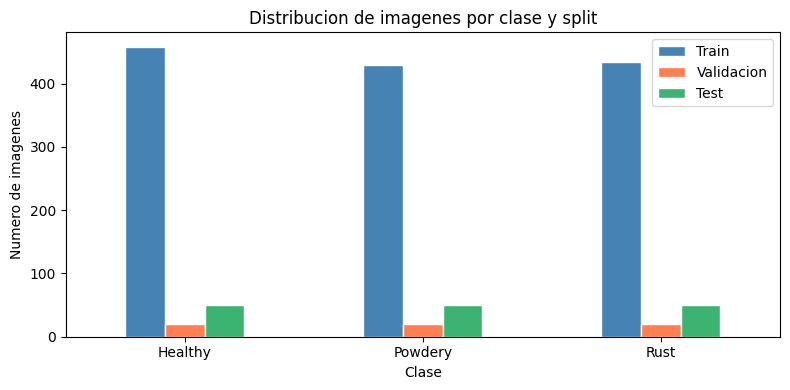

In [24]:


# Conteo de imagenes por clase
def count_images(base_dir):
    counts = {}
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({'Train': train_counts, 'Validacion': val_counts, 'Test': test_counts})
print(df_counts)
print(f"\nTotal — Train: {df_counts['Train'].sum()} | Val: {df_counts['Validacion'].sum()} | Test: {df_counts['Test'].sum()}")

# Grafica de distribución
df_counts.plot(kind='bar', figsize=(8, 4), edgecolor='white', color=['steelblue','coral','mediumseagreen'])
plt.title('Distribucion de imagenes por clase y split')
plt.ylabel('Numero de imagenes')
plt.xlabel('Clase')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()